## General imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## Load preprocessed connectomes from the YRSP sample

We included data from the [Yale Resting State fMRI/Pupillometry: Arousal Study](https://openneuro.org/datasets/ds003673/versions/2.0.1), preprocessed for our introduction paper. 

The data have been copied in a simplified format into the repository, but it is the actual data processed using fMRIprep and XCP-D, and parcellated using the Schaefer200-7Networks parcellation. We have two runs per subject. For the sake of this demonstration, we will stick to `"run-01"`.

Along with the connectomes, we have a file with pupil-derived arousal measurements.

So, let's load the connectomes:

In [2]:
# get file paths, restrict to "run-01"
filepaths_conn = sorted(Path("ds003673-v2.0.1/connectomes").glob("*_run-01_*_pearsonmat.tsv"))
print(f"Found {len(filepaths_conn)} connectome files.")

# load connectomes
data_conn = [pd.read_table(fp, index_col=0) for fp in filepaths_conn]
print("Shape of one connectome:", data_conn[0].shape)

# get a list of subject names from the connectome files
subject_ids = [fp.name.split("_")[0] for fp in filepaths_conn]
print(subject_ids)
data_conn[0].head()

Found 26 connectome files.
Shape of one connectome: (200, 200)
['sub-pa1372', 'sub-pa1387', 'sub-pa1416', 'sub-pa1560', 'sub-pa1582', 'sub-pa1604', 'sub-pa1674', 'sub-pa1700', 'sub-pa1766', 'sub-pa1792', 'sub-pa1811', 'sub-pa1834', 'sub-pa1841', 'sub-pa1859', 'sub-pa1913', 'sub-pa1940', 'sub-pa1978', 'sub-pa2079', 'sub-pa2100', 'sub-pa2106', 'sub-pa2196', 'sub-pa2213', 'sub-pa2216', 'sub-pa2220', 'sub-pa2221', 'sub-pa2226']


,LH_Vis_1,LH_Vis_2,LH_Vis_3,LH_Vis_4,LH_Vis_5,LH_Vis_6,LH_Vis_7,LH_Vis_8,LH_Vis_9,LH_Vis_10,...,RH_Default_PFCdPFCm_1,RH_Default_PFCdPFCm_2,RH_Default_PFCdPFCm_3,RH_Default_PFCdPFCm_4,RH_Default_PFCdPFCm_5,RH_Default_PFCdPFCm_6,RH_Default_PFCdPFCm_7,RH_Default_pCunPCC_1,RH_Default_pCunPCC_2,RH_Default_pCunPCC_3
parcelx,,,,,,,,,,,,,,,,,,,,,
LH_Vis_1,1.0000,0.5378,0.4085,0.1380,-0.0703,-0.1332,0.2489,0.4478,0.3514,0.2611,...,-0.3018,-0.3390,-0.0297,-0.3662,-0.3721,-0.5005,-0.5022,0.1245,-0.2481,-0.0785
LH_Vis_2,0.5378,1.0000,0.5777,0.1048,0.4168,-0.1490,0.4506,0.5490,0.5402,0.0381,...,-0.3023,-0.3613,0.0829,-0.3653,0.0208,-0.4525,-0.3975,-0.3265,-0.3543,-0.5007
LH_Vis_3,0.4085,0.5777,1.0000,-0.2837,0.5563,-0.2772,-0.0437,0.7834,0.4376,-0.3199,...,-0.3540,-0.3366,-0.0483,-0.4154,0.0249,-0.4823,-0.3997,-0.3151,-0.3808,-0.3545
LH_Vis_4,0.1380,0.1048,-0.2837,1.0000,-0.2033,0.2734,0.5810,-0.2279,0.2959,0.7007,...,-0.0776,0.0669,0.2024,-0.0726,-0.0935,-0.1694,-0.1579,0.0338,-0.1525,-0.1716
LH_Vis_5,-0.0703,0.4168,0.5563,-0.2033,1.0000,-0.1054,-0.0576,0.5209,0.4404,-0.3878,...,-0.1897,-0.1042,0.0038,-0.2784,-0.0409,-0.1828,-0.1986,-0.3124,-0.3127,-0.4502


Now, load the pupil data:

In [3]:
# read table, set sub and run as index (first 2 columns)
data_pupil = pd.read_csv("ds003673-v2.0.1/pupil_unrest.csv", index_col=[0,1])

# restrict to run 1 and drop run index
data_pupil = data_pupil.query("run==1").droplevel("run")
print(f"{data_pupil.shape[0]} subjects have pupil data.")
data_pupil.head()

23 subjects have pupil data.


,pui,lf_s,lf_r,hf_p
sub,,,,
sub-pa1372,2.393952,4.781189,3.682644,0.776922
sub-pa1416,2.385295,8.296893,3.610469,0.461461
sub-pa1582,3.243751,3.632503,7.673968,0.901367
sub-pa1604,1.769337,2.672965,1.842291,0.296011
sub-pa1674,5.486865,11.991272,18.366636,4.240835


## Load reference data via NiSpace

We will run a colocalization analysis between our YRSP connectomes and a database of PET maps derived from healthy adult samples. In our companion paper, we termed this analysis "Neurobiologically Enriched Organization of Functional Connectivity: NEOFC".  

These PET maps, we will fetch conveniently via our colocalization toolbox, NiSpace. (In the future, the neofc/mapconn approach will also be integrated into NiSpace.)

In [5]:
# when you installed mapconn, you also installed NiSpace
from nispace.datasets import fetch_reference

# fetch the PET dataset
# the cortical Schaefer200 parcellation is included in NiSpace and data is pre-parcellated.
data_ref = fetch_reference(
    "pet", 
    collection="UniqueTracers", # a subset of PET maps, one for each of all available targets
    parcellation="Schaefer200",
    print_references=False # switch to True to see sources of the PET maps
)

# data_ref is a dataframe with columns by parcel and rows by PET map
print(f"data_ref shape: {data_ref.shape}")

# the index of data_ref has full names of each map as in ('General', 'target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023')
# simplify to, e.g. "target-CMRglu":
data_ref.index = data_ref.index.get_level_values("map").str.split("_").str[0]

# print
data_ref.head()

INFO | 07/05/26 17:18:53 | nispace: Loading pet maps.
INFO | 07/05/26 17:18:53 | nispace: Loading integrated collection 'UniqueTracers' for dataset 'pet'.
INFO | 07/05/26 17:18:53 | nispace: Filtering maps by collection.
INFO | 07/05/26 17:18:53 | nispace: Loading data parcellated with 'Schaefer200'
data_ref shape: (29, 200)


,hemi-L_div-Vis_lab-1,hemi-L_div-Vis_lab-2,hemi-L_div-Vis_lab-3,hemi-L_div-Vis_lab-4,hemi-L_div-Vis_lab-5,hemi-L_div-Vis_lab-6,hemi-L_div-Vis_lab-7,hemi-L_div-Vis_lab-8,hemi-L_div-Vis_lab-9,hemi-L_div-Vis_lab-10,...,hemi-R_div-Default_lab-PFCm+1,hemi-R_div-Default_lab-PFCm+2,hemi-R_div-Default_lab-PFCm+3,hemi-R_div-Default_lab-PFCm+4,hemi-R_div-Default_lab-PFCm+5,hemi-R_div-Default_lab-PFCm+6,hemi-R_div-Default_lab-PFCm+7,hemi-R_div-Default_lab-PCC+1,hemi-R_div-Default_lab-PCC+2,hemi-R_div-Default_lab-PCC+3
map,,,,,,,,,,,,,,,,,,,,,
target-CMRglu,0.559112,0.594449,0.564076,0.666908,0.602571,0.518207,0.688230,0.615766,0.505019,0.620761,...,0.581132,0.538443,0.271502,0.551985,0.546889,0.611242,0.619898,0.549012,0.636247,0.714757
target-rCPS,0.497289,0.557331,0.534445,0.572699,0.641106,0.430567,0.687770,0.589226,0.577158,0.569366,...,0.433393,0.415876,0.254675,0.473352,0.471594,0.504121,0.476509,0.406810,0.456467,0.535884
target-SV2A,0.537978,0.540918,0.548307,0.534142,0.534993,0.447078,0.548369,0.608136,0.502087,0.509273,...,0.587963,0.559697,0.287395,0.572710,0.535124,0.562284,0.537002,0.456903,0.525056,0.629389
target-HDAC,0.553002,0.622292,0.577327,0.657692,0.625431,0.479302,0.700557,0.608080,0.559259,0.579867,...,0.559331,0.513902,0.269002,0.585470,0.579615,0.607215,0.549384,0.495942,0.526574,0.639320
target-VMAT2,0.030641,0.022257,0.017838,0.020735,0.012365,0.017351,0.020118,0.017386,0.010469,0.022985,...,0.026416,0.022107,0.010951,0.017851,0.015094,0.015681,0.016113,0.019956,0.028658,0.027745


## Load parcellation via NiSpace

For the spatial null maps, we need the parcellation and/or a distance matrix corresponding to the parcellation. We can load that easily via NiSpace, too.

In [5]:
from nispace.datasets import fetch_parcellation

# NiSpace returns parcellations as internal Parcellation objects
parc = fetch_parcellation("Schaefer200")

# load a volumetric distance matrix
parc.set_active_space("MNI152NLin2009cAsym")
distmat = parc.get_dist_mat(n_proc=-1)

# show distance matrix
distmat

INFO | 07/05/26 17:08:24 | nispace: Building multi-space Parcellation for 'Schaefer200' from library.
INFO | 07/05/26 17:08:24 | nispace: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsaverage, fsLR
INFO | 07/05/26 17:08:24 | nispace: Parcellation 'Schaefer200': validation passed.
INFO | 07/05/26 17:08:24 | nispace: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.
INFO | 07/05/26 17:08:25 | nispace: Parcellation 'Schaefer200': active space set to 'MNI152NLin2009cAsym'.
INFO | 07/05/26 17:08:25 | nispace: Computing distance matrix for 'Schaefer200' in space 'MNI152NLin2009cAsym'.
INFO | 07/05/26 17:08:25 | nispace: Resampling volumetric parcellation to voxelsize of 2 for distance matrix generation.
INFO | 07/05/26 17:08:25 | nispace: Estimating euclidean distance matrix: 200 volumetric parcels, voxel-to-voxel mode, -1 proc.


Distance matrix (-1 proc):   0%|          | 0/200 [00:00<?, ?it/s]

array([[ 0.      , 27.762733, 29.611572, ..., 46.12255 , 53.085037,
        63.825584],
       [27.762733,  0.      , 25.960722, ..., 55.697994, 64.56949 ,
        71.198654],
       [29.611572, 25.960722,  0.      , ..., 66.82173 , 70.98037 ,
        77.06786 ],
       ...,
       [46.12255 , 55.697994, 66.82173 , ...,  0.      , 23.06399 ,
        32.73802 ],
       [53.085037, 64.56949 , 70.98037 , ..., 23.06399 ,  0.      ,
        22.231543],
       [63.825584, 71.198654, 77.06786 , ..., 32.73802 , 22.231543,
         0.      ]], shape=(200, 200), dtype=float32)

## NEOFC analyis

Finally, our analysis: mapconn is organized in three steps:  

*`mapconn.MapConn`*:  
Initialize the mapconn instance and calculate colocalization statistics from the original input maps (i.e., `AUC+` in the companion paper). The instance can be initialized from connectomes (`MapConn.from_matrix(...)`) or timeseries (`MapConn.from_timeseries(...)`). Here, we of course also need to provide the "map" data, i.e. PET maps in parcellated format.

*`mapconn.MapConnInv`*:  
Calculate inverted statistics (i.e., `AUC–` in the paper), from either the MapConn instance (`MapConnInv.from_mapconn(...)`) or directly from connectomes/timeseries. In the latter case, internally, first a MapConn object is initialized and then passed to the MapConnInv instance.

*`mapconn.MapConnNull`*:  
Calculate subject-level and cohort-level p values by creating n spatial surrogates of the PET maps and re-runnning the whole analysis n times. The only way to run this is via `MapConnNull.from_mapconn(...)` to which either a `MapConn` or a `MapConnInv` instance can be passed. For null map creation, also NiSpace is used. Here, we either need to pass the null maps directly, or the data that NiSpace needs to generate null maps. The required data depends on the approach used to generate the null maps.  
- you can pass the parcellation directly, or a distance matrix: for a volumetric parcellations are passed as niftis, surface parcellations as tuple of gifti files. Distance matrices are passed via `distmat=your_matrix`.
- The null map method (c.f. NiSpace), will by default `method="moran"` because the method (Moran Spectral Randomization) is very flexible.
- Parcellations and distance matrices can be fetched via NiSpace.
- For options, refer to the NiSpace function `nispace.nulls.generate_null_maps()`
- Overall, the handling of parcellation types, null methods, and their connections is not too nicely done, currently. The integration in NiSpace will massively improve this.

In [6]:
from mapconn import MapConnInv

# as outlined above, we can start with a MapConnInv instance if we are interested in the inverted stats anyways
mc = MapConnInv.from_matrix(
    connectivity_matrices=data_conn,  # list of connectomes (numpy arrays, pandas dataframes, ...)
    matrix_ids=subject_ids,  # list of subject IDs corresponding to the connectomes
    map_data=data_ref,  # dataframe with maps as rows and columns as parcels
    r_to_z=True,  # whether to apply Fisher r-to-z transformation to the connectomes
    n_jobs=-1,  # number of parallel jobs to run, -1 to use all available cores
)

INFO:mapconn.mapconn:1225: Flattening connectivity matrices to create MapConnInv (n_jobs=-1, dtype=<class 'numpy.float32'>)
INFO:mapconn.mapconn:700: Flattening connectivity matrices to create MapConn (n_jobs=-1, dtype=<class 'numpy.float32'>)
INFO:mapconn.mapconn:606: Creating MapConn from flattened connectivity matrices (n_jobs=-1, dtype=<class 'numpy.float32'>)
INFO:mapconn.percentiles:42: Got map data with 29 maps and 200 values
INFO:mapconn.percentiles:60: Calculating map percentiles
Calculating mapConn curves: 100%|██████████| 580/580 [00:04<00:00, 133.25it/s]
INFO:mapconn.mapconn:109: Initializing MapConn (n_jobs=-1, dtype=<class 'numpy.float32'>)
INFO:mapconn.mapconn:1086: Creating MapConnInv from MapConn instance (n_jobs=-1, dtype=<class 'numpy.float32'>)
INFO:mapconn.mapconn:606: Creating MapConn from flattened connectivity matrices (n_jobs=-1, dtype=<class 'numpy.float32'>)
INFO:mapconn.percentiles:42: Got map data with 29 maps and 200 values
INFO:mapconn.percentiles:60: Cal

In [7]:
# inspect results
# get_summary() will return a dataframe with the cohort-average AUC values for each PET map
# the returned dataframe will have a multi-index with "original", "inverted", and "delta" as the first level,
# and mean, std, min, and max as the second level.
# show only the original stats:
print("Original stats on group level:")
display(mc.get_summary().loc["original"])

# level="individual" will return the statistics per individual connectome
print("Original stats on individual level (first 5):")
display(mc.get_summary(level="individual").loc["original"].head())

Original stats on group level:


map,target-CMRglu,target-rCPS,target-SV2A,target-HDAC,target-VMAT2,target-TSPO,target-COX1,target-mGluR5,target-NMDA,target-GABAa5,...,target-5HT6,target-5HTT,target-NET,target-A4B2,target-M1,target-VAChT,target-MOR,target-KOR,target-CB1,target-H3
variable,,,,,,,,,,,,,,,,,,,,,
mean,0.010063,0.021363,0.004383,0.005807,0.016779,0.003356,0.054595,0.016000,-0.000172,0.015937,...,0.005888,0.031487,0.068228,0.012127,0.006862,0.068199,0.023570,0.031641,0.009032,0.020893
std,0.007686,0.007761,0.007821,0.008148,0.009483,0.007220,0.013919,0.011141,0.006602,0.011785,...,0.008269,0.011865,0.023917,0.010591,0.008642,0.018230,0.011532,0.011363,0.007708,0.011556
min,-0.001911,0.007793,-0.009275,-0.007253,-0.000639,-0.009474,0.028072,-0.002901,-0.014628,-0.001848,...,-0.006247,0.010233,0.022375,-0.005652,-0.010925,0.026832,0.002661,0.004898,-0.006081,0.002667
max,0.027681,0.040774,0.018466,0.021395,0.037898,0.022636,0.079360,0.041034,0.013075,0.041774,...,0.021817,0.052966,0.108741,0.040192,0.028524,0.117049,0.049284,0.050425,0.022008,0.046301


Original stats on individual level (first 5):


map,target-CMRglu,target-rCPS,target-SV2A,target-HDAC,target-VMAT2,target-TSPO,target-COX1,target-mGluR5,target-NMDA,target-GABAa5,...,target-5HT6,target-5HTT,target-NET,target-A4B2,target-M1,target-VAChT,target-MOR,target-KOR,target-CB1,target-H3
id,,,,,,,,,,,,,,,,,,,,,
sub-pa1372,0.007606,0.021846,0.004722,0.006129,0.007717,0.003196,0.059247,-0.000168,-0.001749,0.006993,...,0.009491,0.029391,0.069450,0.010259,0.007013,0.062192,0.015296,0.019971,0.011007,0.018443
sub-pa1387,0.004568,0.012826,0.005144,0.000122,0.020151,0.004870,0.069437,0.003608,-0.005396,0.020987,...,0.015163,0.028425,0.076514,0.023094,0.000122,0.071764,0.049284,0.023728,0.016466,0.028523
sub-pa1416,0.002685,0.018108,0.009711,0.005656,0.007567,-0.002356,0.048468,0.011816,-0.007017,0.000743,...,0.004586,0.025167,0.095362,0.011165,0.008916,0.083349,0.008933,0.030454,0.012503,0.015151
sub-pa1560,0.004927,0.023774,0.002190,0.005632,0.011403,0.000969,0.063441,0.005620,0.000149,-0.000288,...,0.000041,0.025934,0.046065,0.003586,0.001971,0.052514,0.009660,0.021580,0.006454,0.002865
sub-pa1582,0.010076,0.026958,0.000729,0.000799,0.032729,0.001271,0.031111,0.015165,0.002960,0.032255,...,0.009604,0.041111,0.022375,0.007339,0.005004,0.040277,0.023609,0.014070,0.013169,0.019424


### Estimate p values via spatial null models

This will take about 5 minutes max with 8 parallel processes.

In [8]:
from mapconn import MapConnNull

mc_null = MapConnNull.from_mapconn(
    mc, # our MapConn instance
    distmat=distmat, # distance matrix for the parcellation. If that is passed, no parcellation=... is necessary
    n_nulls=1000, # number of nulls to generate, 10000 if you want to be very sure
    n_jobs=-1, # number of parallel jobs to run, -1 to use all available cores
    seed=42, # random seed for reproducibility
)

INFO:mapconn.mapconn:2497: Creating MapConnNull instance from MapConnInv instance (n_nulls=1000, dype=None, n_jobs=-1)
INFO:mapconn.mapconn:2547: Generating null maps
Calculating null mapconn curves: 100%|██████████| 1000/1000 [02:12<00:00,  7.54it/s]
INFO:mapconn.mapconn:1352: Initializing MapConnNull (n_nulls=1000, n_jobs=-1, dtype=<class 'numpy.float32'>)
INFO:mapconn.mapconn:2398: Pre-computing stats
INFO:mapconn.mapconn:2405: Pre-computing p-values (1/4): level=group, source=inverted
INFO:mapconn.mapconn:2405: Pre-computing p-values (2/4): level=group, source=observed
INFO:mapconn.mapconn:2405: Pre-computing p-values (3/4): level=individual, source=inverted
INFO:mapconn.mapconn:2405: Pre-computing p-values (4/4): level=individual, source=observed
INFO:mapconn.mapconn:2417: Pre-computing null curve distributions
INFO:mapconn.mapconn:2419: Pre-computing null stats distributions


In [9]:
# inspect null results
# the null object also has a get_summary() method that returns the same dataframe as above,
# but now it also includes p values and null distribution statistics
# here, "mean" is the AUC mean, "mean_z" and "mean_rz" are the AUC means standardized against 
# the null distribution (rz -> robust z-score).
print("Null stats on group level:")
display(mc_null.get_summary().loc["original"])

# level="individual" will return the statistics per individual connectome with one additional
# index column "variable" with values: "val", "p", and individual-level null distribution stats
print("Null stats on individual level (first 5):")
display(mc_null.get_summary(level="individual").loc["original"].head())

Null stats on group level:


map,target-CMRglu,target-rCPS,target-SV2A,target-HDAC,target-VMAT2,target-TSPO,target-COX1,target-mGluR5,target-NMDA,target-GABAa5,...,target-5HT6,target-5HTT,target-NET,target-A4B2,target-M1,target-VAChT,target-MOR,target-KOR,target-CB1,target-H3
variable,,,,,,,,,,,,,,,,,,,,,
mean,0.010063,0.021363,0.004383,0.005807,0.016779,0.003356,0.054595,0.016000,-0.000172,0.015937,...,0.005888,0.031487,0.068228,0.012127,0.006862,0.068199,0.023570,0.031641,0.009032,0.020893
mean_rz,0.798601,0.932289,-0.486133,-0.124697,0.839026,-0.287961,4.166905,1.009790,-0.838478,0.034043,...,-0.291400,1.548541,6.072927,0.493722,-0.346765,4.795015,0.414658,1.627617,0.288842,1.121261
mean_z,0.581562,0.633817,-0.628955,-0.253334,0.628223,-0.461836,2.989493,0.806272,-0.960001,-0.249610,...,-0.442116,1.049316,5.503831,0.254431,-0.449726,4.879736,0.004368,1.454832,0.029224,0.807043
std,0.007686,0.007761,0.007821,0.008148,0.009483,0.007220,0.013919,0.011141,0.006602,0.011785,...,0.008269,0.011865,0.023917,0.010591,0.008642,0.018230,0.011532,0.011363,0.007708,0.011556
min,-0.001911,0.007793,-0.009275,-0.007253,-0.000639,-0.009474,0.028072,-0.002901,-0.014628,-0.001848,...,-0.006247,0.010233,0.022375,-0.005652,-0.010925,0.026832,0.002661,0.004898,-0.006081,0.002667
max,0.027681,0.040774,0.018466,0.021395,0.037898,0.022636,0.079360,0.041034,0.013075,0.041774,...,0.021817,0.052966,0.108741,0.040192,0.028524,0.117049,0.049284,0.050425,0.022008,0.046301
p,0.232000,0.217000,0.712000,0.554000,0.246000,0.612000,0.018000,0.219000,0.848000,0.485000,...,0.623000,0.146000,0.001000,0.348000,0.620000,0.001000,0.371000,0.095000,0.390000,0.210000
null_count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
null_mean,0.005621,0.014152,0.010381,0.007949,0.010953,0.007644,0.015265,0.008517,0.009916,0.019363,...,0.010448,0.018162,0.008084,0.009733,0.011417,0.012368,0.023500,0.014789,0.008753,0.012464


Null stats on individual level (first 5):


map                  target-CMRglu  target-rCPS  target-SV2A  target-HDAC  \
variable id                                                                 
val      sub-pa1372       0.007606     0.021846     0.004722     0.006129   
         sub-pa1387       0.004568     0.012826     0.005144     0.000122   
         sub-pa1416       0.002685     0.018108     0.009711     0.005656   
         sub-pa1560       0.004927     0.023774     0.002190     0.005632   
         sub-pa1582       0.010076     0.026958     0.000729     0.000799   

map                  target-VMAT2  target-TSPO  target-COX1  target-mGluR5  \
variable id                                                                  
val      sub-pa1372      0.007717     0.003196     0.059247      -0.000168   
         sub-pa1387      0.020151     0.004870     0.069437       0.003608   
         sub-pa1416      0.007567    -0.002356     0.048468       0.011816   
         sub-pa1560      0.011403     0.000969     0.063441       0.005620   
         sub-pa1582      0.032729     0.001271     0.031111       0.015165   

map                  target-NMDA  target-GABAa5  ...  target-5HT6  \
variable id                                      ...                
val      sub-pa1372    -0.001749       0.006993  ...     0.009491   
         sub-pa1387    -0.005396       0.020987  ...     0.015163   
         sub-pa1416    -0.007017       0.000743  ...     0.004586   
         sub-pa1560     0.000149      -0.000288  ...     0.000041   
         sub-pa1582     0.002960       0.032255  ...     0.009604   

map                  target-5HTT  target-NET  target-A4B2  target-M1  \
variable id                                                            
val      sub-pa1372     0.029391    0.069450     0.010259   0.007013   
         sub-pa1387     0.028425    0.076514     0.023094   0.000122   
         sub-pa1416     0.025167    0.095362     0.011165   0.008916   
         sub-pa1560     0.025934    0.046065     0.003586   0.001971   
         sub-pa1582     0.041111    0.022375     0.007339   0.005004   

map                  target-VAChT  target-MOR  target-KOR  target-CB1  \
variable id                                                             
val      sub-pa1372      0.062192    0.015296    0.019971    0.011007   
         sub-pa1387      0.071764    0.049284    0.023728    0.016466   
         sub-pa1416      0.083349    0.008933    0.030454    0.012503   
         sub-pa1560      0.052514    0.009660    0.021580    0.006454   
         sub-pa1582      0.040277    0.023609    0.014070    0.013169   

map                  target-H3  
variable id                     
val      sub-pa1372   0.018443  
         sub-pa1387   0.028523  
         sub-pa1416   0.015151  
         sub-pa1560   0.002865  
         sub-pa1582   0.019424  

[5 rows x 29 columns]

## Plot results

### Connectivity-vs-percentile curves

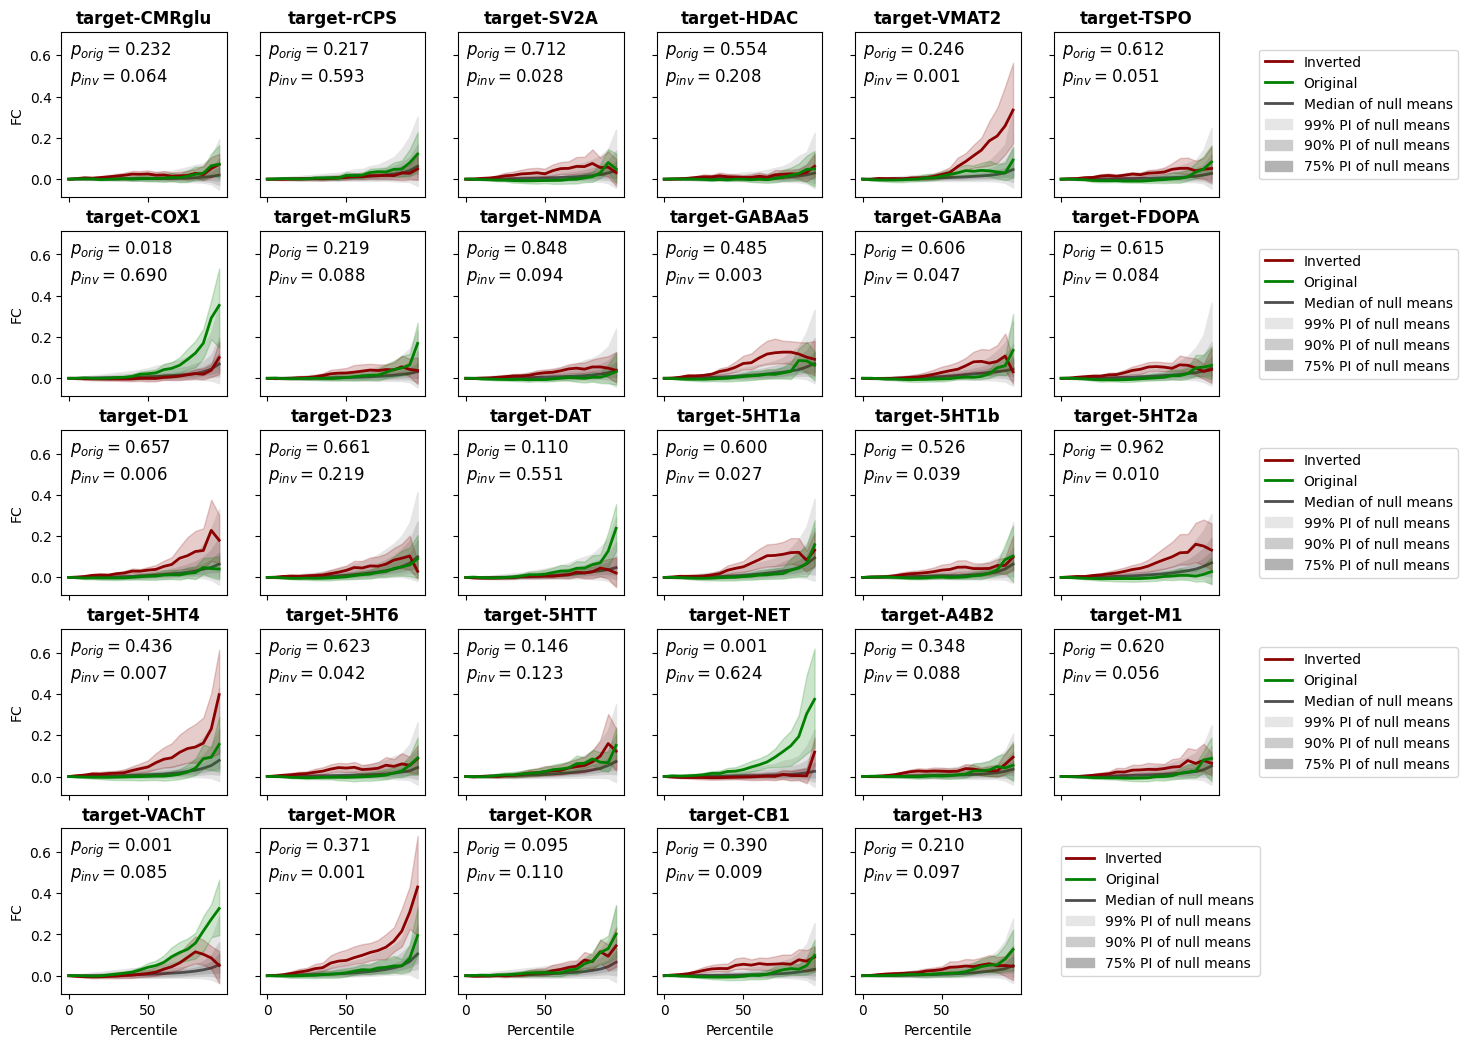

In [10]:
# integrated function to plot curves
from mapconn.plot import plot_mapconn_curves

# plot inverted curves
fig, axes = plot_mapconn_curves(
    mc.get_inverted_curves(), # function to fetch inverted curves
    sharey=True, # whether to share y-axis across subplots
    colors="darkred", # color for the original curves
    plot_kws={"plot_individual": False, "label": "Inverted"} # turned off because we have so many subjects
)

# plot original curves on top
fig, axes = plot_mapconn_curves(
    mc.get_curves(), # function to fetch original curves
    mc_null.get_null_curves_dist(), # function to fetch distribution statistics of null curves
    sharey=True, # whether to share y-axis across subplots
    colors="green", # color for the original curves
    plot_kws={"plot_individual": False, "label": "Original"}, # turned off because we have so many subjects
    fig=fig, axes=axes # pass the same figure and axes to plot on top of the original curves
)

# add p values to each plot
p_original = mc_null.get_summary().loc[("original", "p")]
p_inverted = mc_null.get_summary().loc[("inverted", "p")]
for ax in axes.flatten():
    # add p values if ax has a title that is in the p_values index (e.g. "target-CMRglu")
    s = ax.get_title()
    if s in p_original.index:
        ax.annotate(f"$p_{{orig}} = {p_original.loc[s]:.3f}$\n$p_{{inv}} = {p_inverted.loc[s]:.3f}$", 
                    xy=(0.05, 0.95), xycoords="axes fraction", ha="left", va="top", fontsize=12)

### Plot a single curve

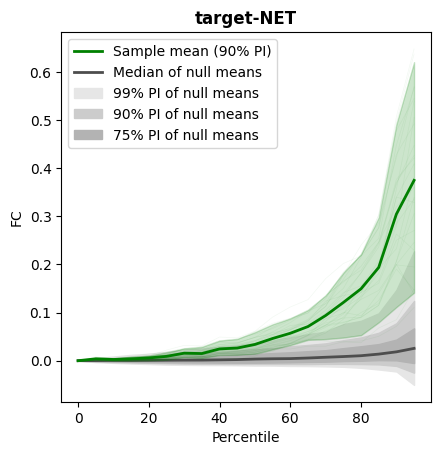

In [11]:
from mapconn.plot import plot_mapconn_curve

ax = plot_mapconn_curve(
    mc.get_curves(maps="target-NET"),
    mc_null.get_null_curves_dist(maps="target-NET"),
    ind_alpha=0.05, # make individual curves more transparent
    color="green"
)
ax.set_box_aspect(1)

### Custom plot of results

C.f. companion paper.  
We see that we can reliably reproduce the strongest effects from our initial analyses.  
COX1 was not in the original paper and is of course interesting, though harder to interpret because it is not directly neuron-related.

Text(0, 0.5, 'PET map')

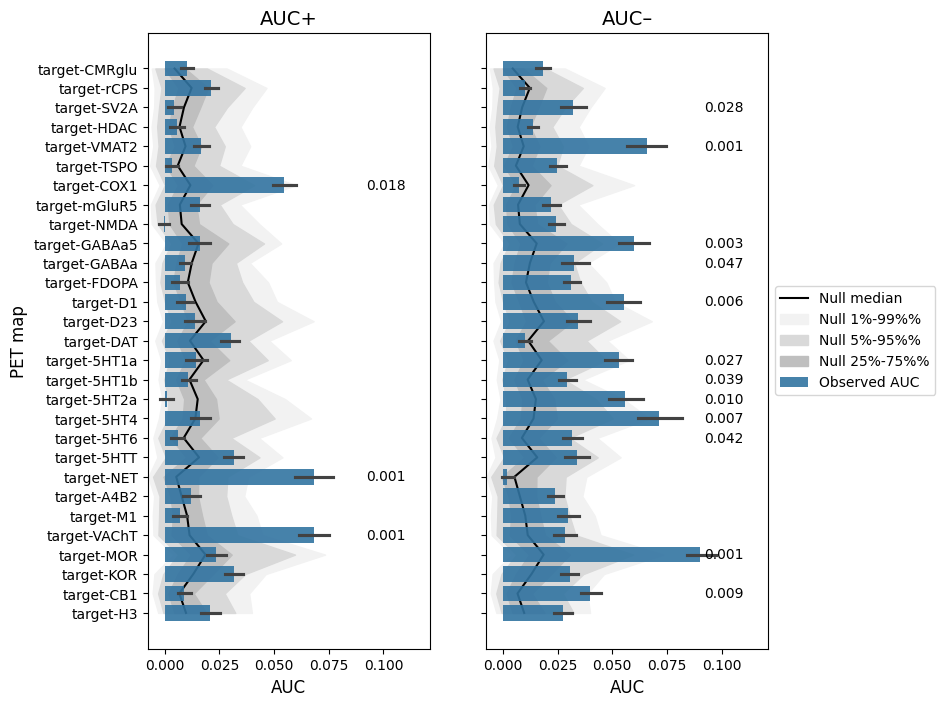

In [12]:
# turn this on or off to show AUC values either raw or scaled against the null distribution (z or rz)
null_standardized = "" # options: "", "_z", "_rz"
assert null_standardized in ["", "_z", "_rz"], "null_standardized must be one of '', '_z', or '_rz'"

# all plot data is available in the summary dataframes
df_summary_group = mc_null.get_summary()
df_summary_indiv = mc_null.get_summary(level="individual")

# init figure
fig, axes = plt.subplots(1, 2, figsize=(8,8), sharey=True, sharex=True)

# plot individual AUC scores as barplot -> original
sns.barplot(df_summary_indiv.loc["original", "val"+null_standardized, :].melt(), x="value", y="map", 
            ax=axes[0], alpha=0.9)
# plot individual AUC scores as barplot -> inverted
sns.barplot(df_summary_indiv.loc["inverted", "val"+null_standardized, :].melt(), x="value", y="map",
            ax=axes[1], alpha=0.9, label="Observed AUC")

# plot p values
x = np.diff(axes[0].get_xlim())
axes[0].set_xlim(None, x + x * 0.1)
axes[1].set_xlim(None, x + x * 0.1)
for l in axes[0].get_yticklabels():
    t = l.get_text()
    y = l.get_position()[1]
    p_original = df_summary_group.loc[('original', 'p'), t]
    p_inverted = df_summary_group.loc[('inverted', 'p'), t]
    # original
    if p_original < 0.05:
        axes[0].annotate(f"{p_original:.3f}", xy=(x, y), xycoords="data", ha="right", va="center", fontsize=10)
    # inverted
    if p_inverted < 0.05:
        axes[1].annotate(f"{p_inverted:.3f}", xy=(x, y), xycoords="data", ha="right", va="center", fontsize=10)

        
# plot null distributions of group-average values into both plots
# plot only for raw values
if not null_standardized:
    for ax in axes:
        # median
        ax.plot(df_summary_group.loc[("original", "null_50%")], df_summary_group.columns, color="k", label="Null median", zorder=-10)
        # percentiles
        for p1, p2, c in [("1%", "99%", "0.95"), ("5%", "95%", "0.85"), ("25%", "75%", "0.75")]:
            ax.fill_betweenx(
                y=df_summary_group.columns, 
                x1=df_summary_group.loc[("original", f"null_{p1}")], 
                x2=df_summary_group.loc[("original", f"null_{p2}")],
                color=c, label=f"Null {p1}-{p2}%", zorder=-11
            )

# legends
axes[0].legend().set_visible(False)
axes[1].legend(loc="center left", bbox_to_anchor=(1, 0.5))

# labels
axes[0].set_title("AUC+", fontsize=14)
axes[1].set_title("AUC–", fontsize=14)
axes[0].set_xlabel("AUC" + (" (normalized)" if null_standardized else ""), fontsize=12)
axes[1].set_xlabel("AUC" + (" (normalized)" if null_standardized else ""), fontsize=12)
axes[0].set_ylabel("PET map", fontsize=12)

### Correlation to an external variable

NEOFC scores can be easily used as imaging phenotypes for further group comparison and association analyses.  
Let's reproduce the correlation between NET AUC+ and pupil unrest. We will perform a simplified version of the analysis reported in our paper by just running a spearman correlation between NET AUC+ scores and the pupil unrest index.

In [29]:
# 1. get pupil unrest scores
scores_pui = data_pupil["pui"] # there are multiple indices of slow pupil fluctuations in the table
print("scores_pui:", scores_pui.shape)
display(scores_pui.head())

# 2. fetch NET AUC+ scores
scores_net = mc.get_stats(maps="target-NET").squeeze() # squeeze reduces the one-column output to a Series
print("scores_net:", scores_net.shape)
# restrict to subjects with pupil data
scores_net = scores_net[scores_pui.index]
print("scores_net after subject selection:", scores_net.shape)
display(scores_net.head())

# simple spearman correlation
from scipy.stats import spearmanr
r, p = spearmanr(scores_net, scores_pui)
print(f"Spearman's rho = {r:.02f}, p = {p:.03f}")

scores_pui: (23,)


sub
sub-pa1372    2.393952
sub-pa1416    2.385295
sub-pa1582    3.243751
sub-pa1604    1.769337
sub-pa1674    5.486865
Name: pui, dtype: float64

scores_net: (26,)
scores_net after subject selection: (23,)


sub
sub-pa1372    0.069450
sub-pa1416    0.095362
sub-pa1582    0.022375
sub-pa1604    0.030765
sub-pa1674    0.100301
Name: target-NET, dtype: float64

Spearman's rho = 0.62, p = 0.002


Correlation between pupil unrest and the NET AUC is 0.62, only using the first run of the fMRI data (mixed linear model with two runs in the paper).  

A simple plot of this relationship:

Text(0, 0.5, 'NET AUC+')

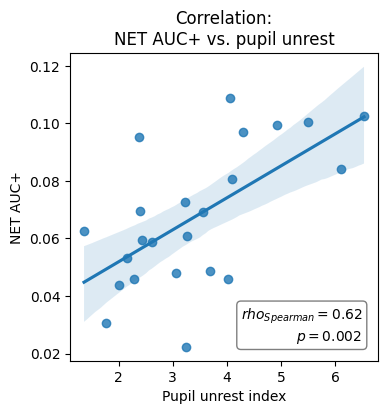

In [30]:
# init
fig, ax = plt.subplots(figsize=(4,4))
ax.set_box_aspect(1)

# regression line and scatter points
sns.regplot(x=scores_pui, y=scores_net)

# labels
ax.annotate(
    f"$rho_{{Spearman}} = {r:.02f}$\n$p = {p:.03f}$",
    xy=(0.95, 0.05), xycoords="axes fraction", ha="right", va="bottom",
    bbox={"boxstyle": "round", "fc": "w", "alpha": 0.5}
)
ax.set_title(f"Correlation:\nNET AUC+ vs. pupil unrest")
ax.set_xlabel("Pupil unrest index")
ax.set_ylabel("NET AUC+")